# 1. Data Loading and Initial Inspection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
# Assuming the data is saved as 'crop_yield_dataset.csv'
# We'll read it directly from the text provided in the prompt
from io import StringIO
data_string = """Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
...""" # Placeholder for the full data

# In a real scenario, you'd read it from a file.
# For this example, we'll create a variable 'df' to hold the data after it's loaded.
# The below code assumes 'data_string' contains the full CSV string.
# Since we can't include the full data here, the following code is for demonstration.


#from google.colab import files

#uploaded = files.upload()

#for fn in uploaded.keys(): print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

df = pd.read_csv('crop_yield_dataset.csv')

# 1. Data Inspection
print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())
print(f"\nDataset Shape: {df.shape}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

# 2. Summary Statistics
print("\nDescriptive Statistics for Numerical Features:")
print(df.describe())

# 3. Data Types
print("\nData Types:")
print(df.dtypes)

# 4. Categorical Features
categorical_cols = ['Region', 'Soil_Type', 'Crop', 'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition']
for col in categorical_cols:
    print(f"\nValue Counts for '{col}':")
    print(df[col].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13938 entries, 0 to 13937
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Region                  13938 non-null  object 
 1   Soil_Type               13938 non-null  object 
 2   Crop                    13938 non-null  object 
 3   Rainfall_mm             13938 non-null  float64
 4   Temperature_Celsius     13938 non-null  float64
 5   Fertilizer_Used         13937 non-null  object 
 6   Irrigation_Used         13937 non-null  object 
 7   Weather_Condition       13937 non-null  object 
 8   Days_to_Harvest         13937 non-null  float64
 9   Yield_tons_per_hectare  13937 non-null  float64
dtypes: float64(4), object(6)
memory usage: 1.1+ MB
None

First 5 rows:
  Region Soil_Type     Crop  Rainfall_mm  Temperature_Celsius Fertilizer_Used  \
0   West     Sandy   Cotton   897.077239            27.676966           False   
1  Sout

In [ ]:
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122.0,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140.0,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106.0,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146.0,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110.0,7.248251



# **2. Exploratory Data Analysis (EDA)**
2.1 Target Variable Analysis



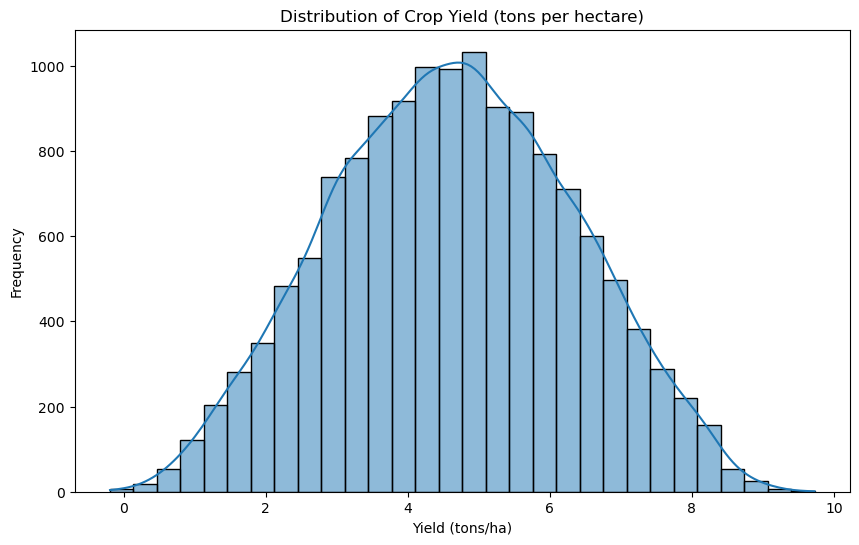

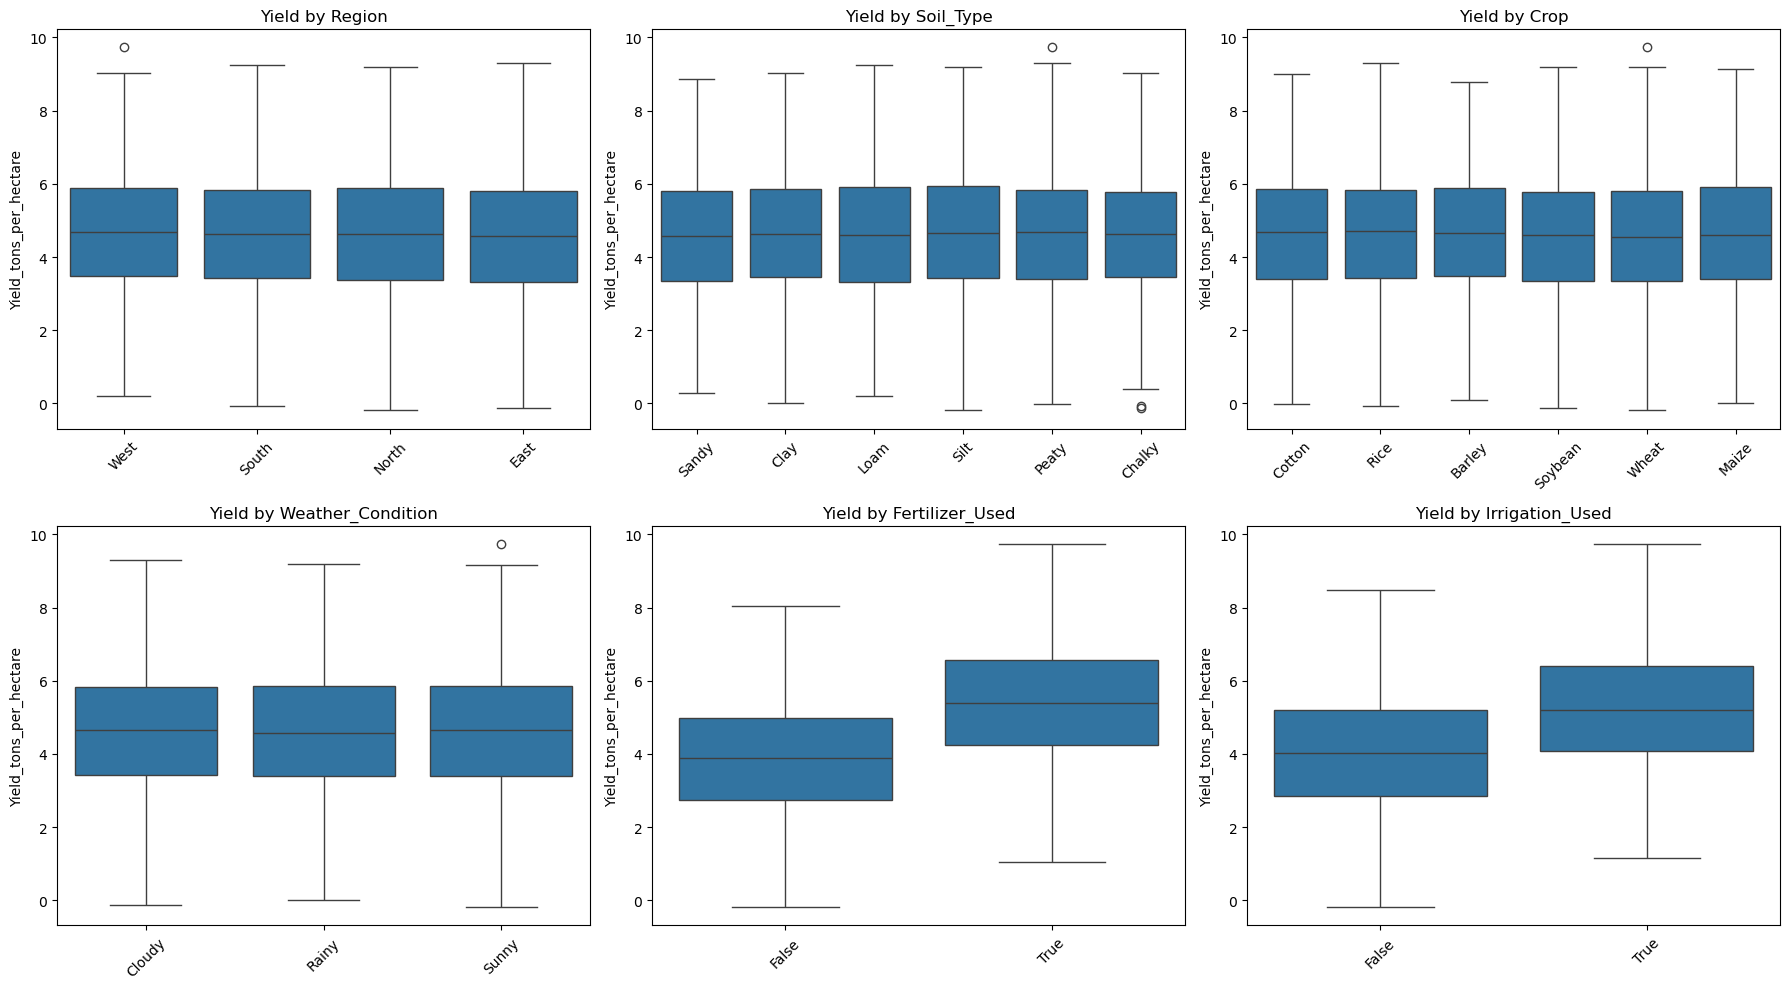

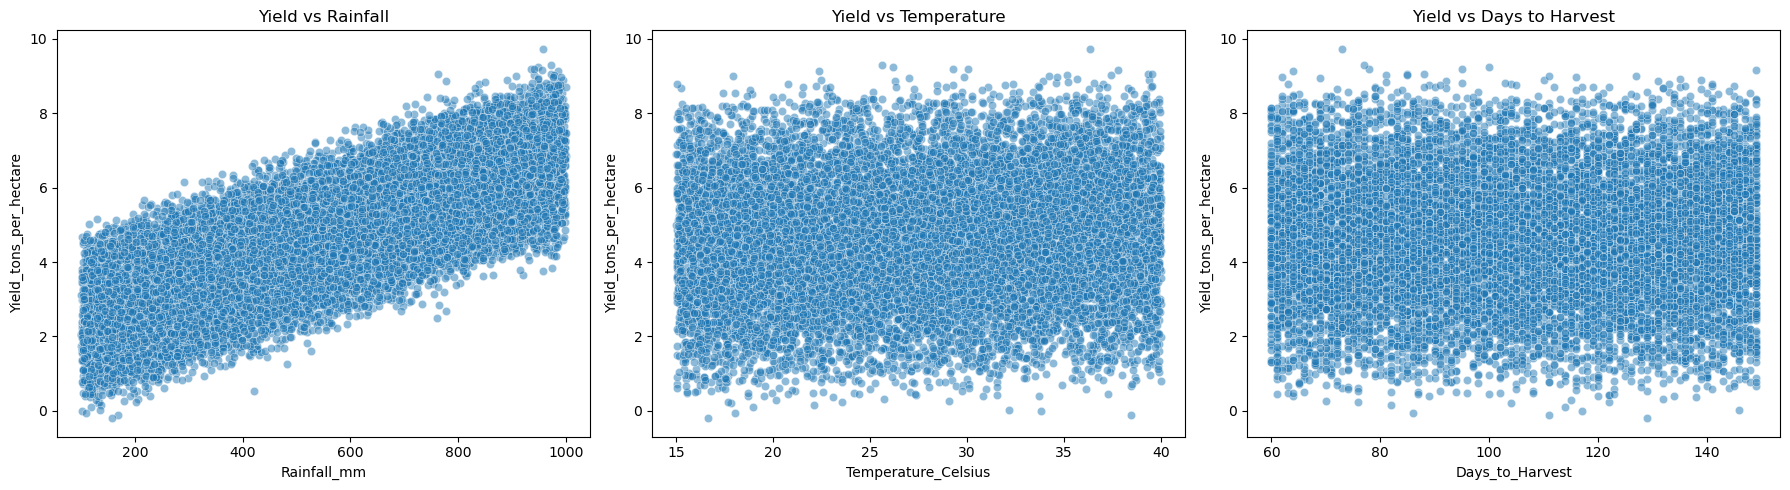

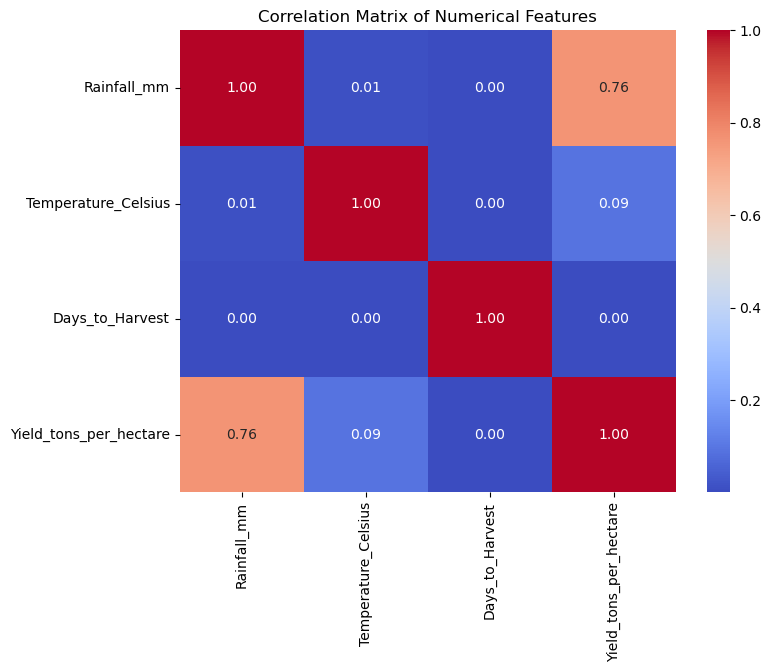

In [ ]:
# 5. Visualizations

# 5.1. Distribution of Yield
plt.figure(figsize=(10, 6))
sns.histplot(df['Yield_tons_per_hectare'], kde=True, bins=30)
plt.title('Distribution of Crop Yield (tons per hectare)')
plt.xlabel('Yield (tons/ha)')
plt.ylabel('Frequency')
plt.show()

# 5.2. Boxplots for Categorical Variables vs Yield
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
categorical_cols_plot = ['Region', 'Soil_Type', 'Crop', 'Weather_Condition', 'Fertilizer_Used', 'Irrigation_Used']
for i, col in enumerate(categorical_cols_plot):
    row, col_idx = i // 3, i % 3
    sns.boxplot(x=col, y='Yield_tons_per_hectare', data=df, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'Yield by {col}')
    axes[row, col_idx].set_xlabel('')
    axes[row, col_idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Observations:
# - Some crops (like Maize, Rice, Wheat) may have higher median yields.
# - Fertilizer and Irrigation usage appear to positively impact yield.
# - The effect of Region and Weather Condition is also notable.

# 5.3. Scatter Plots for Numerical Features vs Yield
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x='Rainfall_mm', y='Yield_tons_per_hectare', data=df, ax=axes[0], alpha=0.5)
axes[0].set_title('Yield vs Rainfall')
sns.scatterplot(x='Temperature_Celsius', y='Yield_tons_per_hectare', data=df, ax=axes[1], alpha=0.5)
axes[1].set_title('Yield vs Temperature')
sns.scatterplot(x='Days_to_Harvest', y='Yield_tons_per_hectare', data=df, ax=axes[2], alpha=0.5)
axes[2].set_title('Yield vs Days to Harvest')
plt.tight_layout()
plt.show()

# Observations:
# - Rainfall shows a moderate positive correlation with yield.
# - Temperature shows a weak correlation; high temperatures may reduce yield.
# - Days to Harvest seems to have a weak positive correlation.

# 5.4. Correlation Matrix (Numerical Features)
plt.figure(figsize=(8, 6))
corr_matrix = df[['Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest', 'Yield_tons_per_hectare']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

2 Feature Engineering Selection


--- Feature Importance from Random Forest ---
                    Feature  Importance
0               Rainfall_mm    0.602545
16     Fertilizer_Used_True    0.200651
17     Irrigation_Used_True    0.123232
1       Temperature_Celsius    0.028988
2           Days_to_Harvest    0.016859
18  Weather_Condition_Rainy    0.002105
5               Region_West    0.002055
19  Weather_Condition_Sunny    0.001985
4              Region_South    0.001939
6            Soil_Type_Clay    0.001904
15               Crop_Wheat    0.001892
3              Region_North    0.001866
11              Crop_Cotton    0.001838
12               Crop_Maize    0.001771
8           Soil_Type_Peaty    0.001763
13                Crop_Rice    0.001754
7            Soil_Type_Loam    0.001746
9           Soil_Type_Sandy    0.001740
10           Soil_Type_Silt    0.001697
14             Crop_Soybean    0.001668


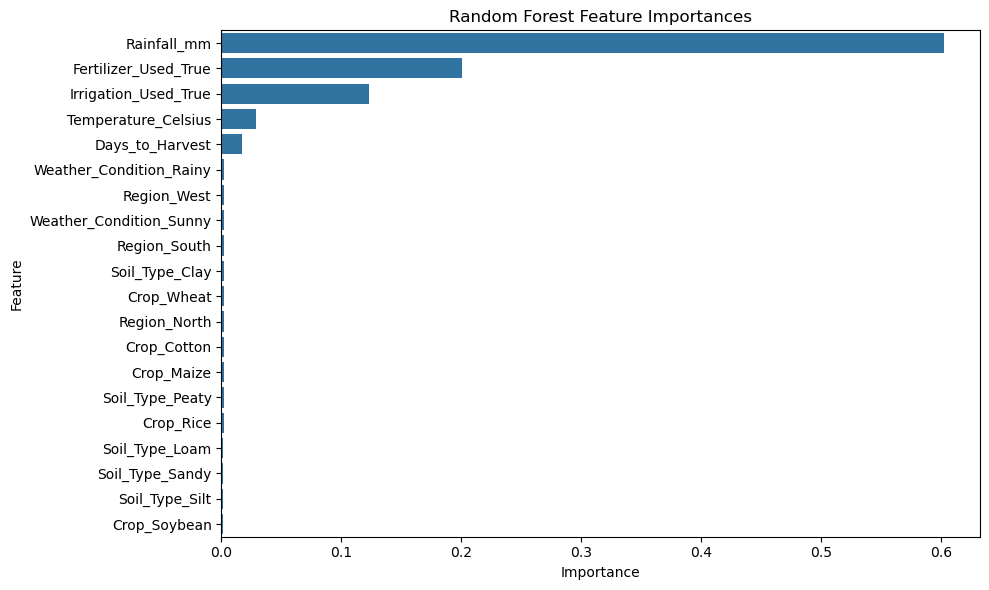


--- Permutation Importance ---
                    Feature  Importance
0               Rainfall_mm    1.132735
16     Fertilizer_Used_True    0.382597
17     Irrigation_Used_True    0.239136
1       Temperature_Celsius    0.012618
10           Soil_Type_Silt    0.000265
11              Crop_Cotton    0.000190
2           Days_to_Harvest    0.000173
7            Soil_Type_Loam    0.000116
14             Crop_Soybean    0.000090
12               Crop_Maize    0.000023
4              Region_South    0.000018
9           Soil_Type_Sandy   -0.000012
5               Region_West   -0.000069
19  Weather_Condition_Sunny   -0.000080
13                Crop_Rice   -0.000092
15               Crop_Wheat   -0.000097
6            Soil_Type_Clay   -0.000097
8           Soil_Type_Peaty   -0.000107
3              Region_North   -0.000157
18  Weather_Condition_Rainy   -0.000161

--- SelectKBest (F-regression) ---
                    Feature       F_Score
0               Rainfall_mm  15306.684420
16     F

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

print("\n--- Feature Importance from Random Forest ---")

# 1. Separate features and target
X = df.drop(columns=['Yield_tons_per_hectare'])
y = df['Yield_tons_per_hectare']

# 2. Convert text/categorical columns into numeric (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Clean missing values from y (~ keeps non-NaN values)
mask_train = ~y_train.isna()
X_train_clean = X_train[mask_train]
y_train_clean = y_train[mask_train]

mask_test = ~y_test.isna()
X_test_clean = X_test[mask_test]
y_test_clean = y_test[mask_test]

# 5. Fit Random Forest on clean numerical data
rf_base = RandomForestRegressor(n_estimators=100, random_state=42)
rf_base.fit(X_train_clean, y_train_clean)

# Extract feature importances
feature_importances = rf_base.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values('Importance', ascending=False)
print(importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()

# 6. Permutation Importance
print("\n--- Permutation Importance ---")
perm_importance = permutation_importance(rf_base, X_test_clean, y_test_clean, n_repeats=10, random_state=42)
perm_importance_df = pd.DataFrame({'Feature': features, 'Importance': perm_importance.importances_mean})
perm_importance_df = perm_importance_df.sort_values('Importance', ascending=False)
print(perm_importance_df)

# 7. SelectKBest (F-regression)
print("\n--- SelectKBest (F-regression) ---")
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_train_clean, y_train_clean)
f_scores = selector.scores_
f_score_df = pd.DataFrame({'Feature': features, 'F_Score': f_scores})
f_score_df = f_score_df.sort_values('F_Score', ascending=False)
print(f_score_df)

# 3.0 **Modelling**

Model Evaluation on Test Set:
----------------------------------------
Random Forest        | MAE: 0.4241 | RMSE: 0.5305 | R2: 0.9056
XGBoost              | MAE: 0.4115 | RMSE: 0.5158 | R2: 0.9108
Gradient Boosting    | MAE: 0.4038 | RMSE: 0.5042 | R2: 0.9147
Stacking Ensemble    | MAE: 0.4289 | RMSE: 0.5387 | R2: 0.9026


Model Performance Summary:
                        MAE      RMSE        R2
Random Forest      0.424087  0.530458  0.905595
XGBoost            0.411543  0.515767  0.910752
Gradient Boosting  0.403811  0.504167  0.914721
Stacking Ensemble  0.428868  0.538730  0.902628


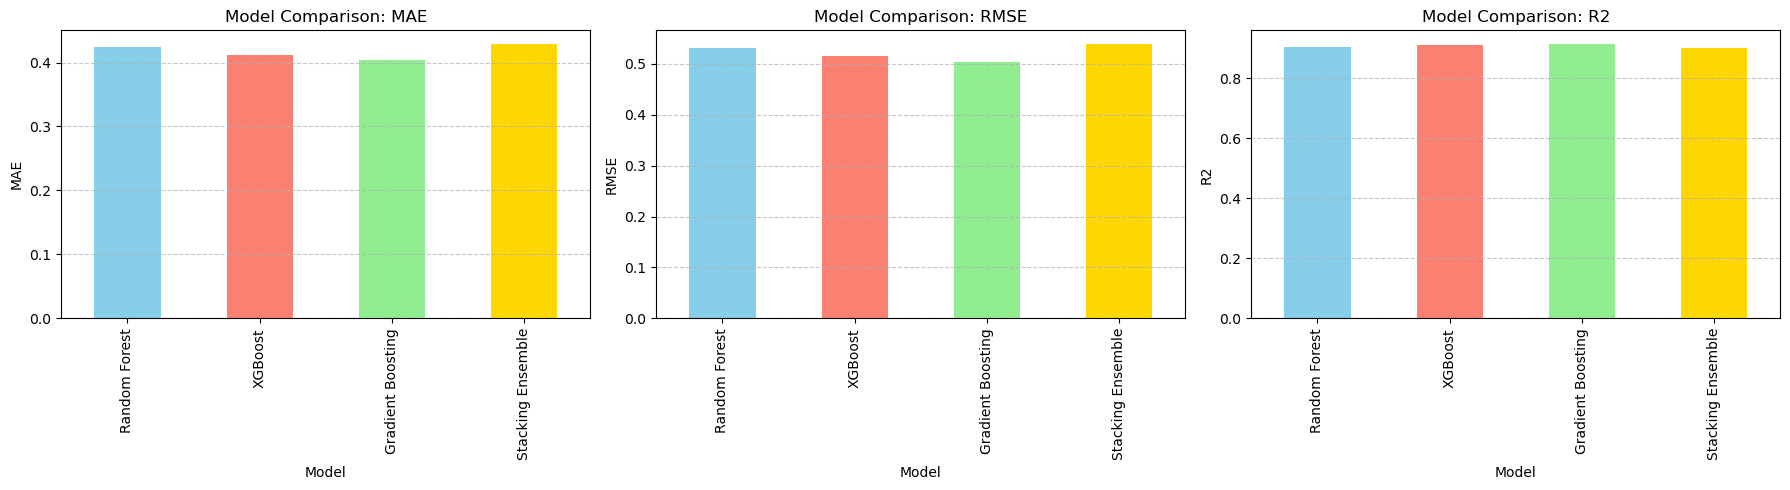


--- Feature Importance from Random Forest (Final Model) ---
                    Feature  Importance
0               Rainfall_mm    0.602545
16     Fertilizer_Used_True    0.200651
17     Irrigation_Used_True    0.123232
1       Temperature_Celsius    0.028988
2           Days_to_Harvest    0.016859
18  Weather_Condition_Rainy    0.002105
5               Region_West    0.002055
19  Weather_Condition_Sunny    0.001985
4              Region_South    0.001939
6            Soil_Type_Clay    0.001904
15               Crop_Wheat    0.001892
3              Region_North    0.001866
11              Crop_Cotton    0.001838
12               Crop_Maize    0.001771
8           Soil_Type_Peaty    0.001763
13                Crop_Rice    0.001754
7            Soil_Type_Loam    0.001746
9           Soil_Type_Sandy    0.001740
10           Soil_Type_Silt    0.001697
14             Crop_Soybean    0.001668


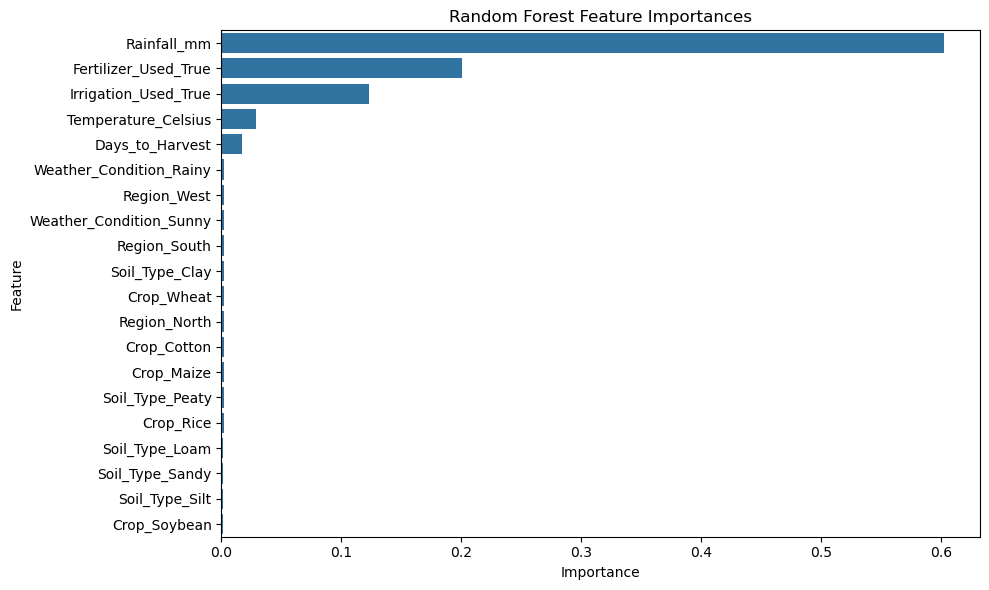


Best Model based on R2: Gradient Boosting


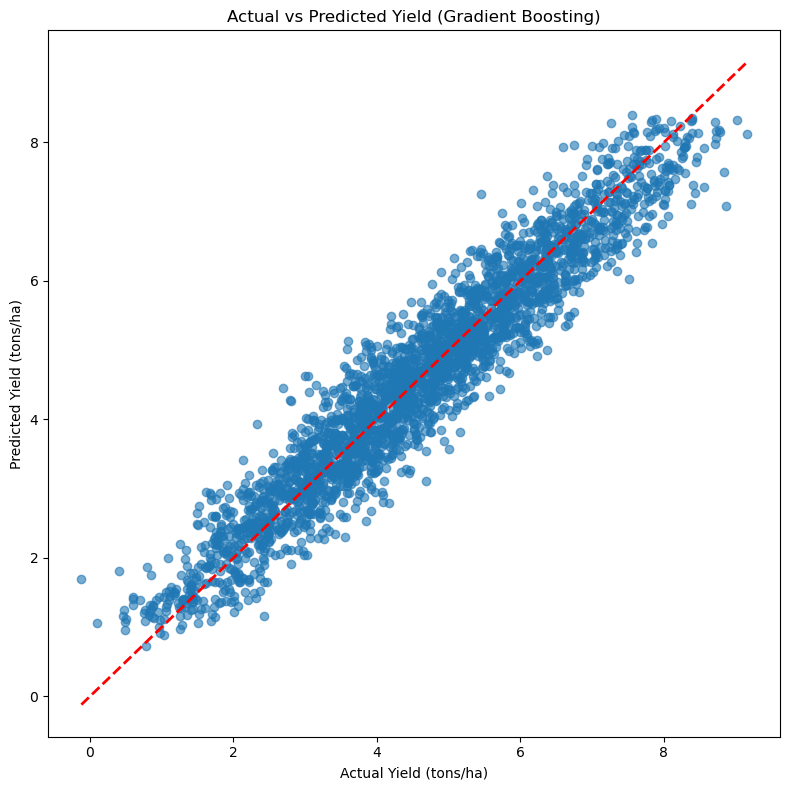

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Clean NaN values from target arrays (y) and align feature matrices (X)
mask_train = ~y_train.isna()
X_train_clean = X_train[mask_train]
y_train_clean = y_train[mask_train]

mask_test = ~y_test.isna()
X_test_clean = X_test[mask_test]
y_test_clean = y_test[mask_test]

# 2. Evaluation function
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return mae, rmse, r2, y_pred

# 3. Model Evaluation on Test Set
results = {}
predictions = {}

print("Model Evaluation on Test Set:")
print("-" * 40)

for name, model in models.items():
    # Pass clean dataset variables here
    mae, rmse, r2, y_pred = evaluate_model(
        model, X_train_clean, X_test_clean, y_train_clean, y_test_clean
    )
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    predictions[name] = y_pred
    print(f"{name:20} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")

# Model Performance Summary
results_df = pd.DataFrame(results).T
print("\n\nModel Performance Summary:")
print(results_df)

# Visualization of Model Performance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['MAE', 'RMSE', 'R2']
for i, metric in enumerate(metrics):
    ax = axes[i]
    results_df[metric].plot(kind='bar', ax=ax, color=['skyblue', 'salmon', 'lightgreen', 'gold'])
    ax.set_title(f'Model Comparison: {metric}')
    ax.set_ylabel(metric)
    ax.set_xlabel('Model')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Feature Importance from Random Forest
print("\n--- Feature Importance from Random Forest (Final Model) ---")
rf_model = models['Random Forest']
rf_model.fit(X_train_clean, y_train_clean)

importance = rf_model.feature_importances_
feature_names = X.columns
importance_dict = dict(zip(feature_names, importance))
importance_df = pd.DataFrame(list(importance_dict.items()), columns=['Feature', 'Importance'])
importance_df = importance_df.sort_values('Importance', ascending=False)
print(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()

# Scatter plot of Actual vs Predicted for Best Model
best_model_name = results_df['R2'].idxmax()
print(f"\nBest Model based on R2: {best_model_name}")

y_pred_best = predictions[best_model_name]

plt.figure(figsize=(8, 8))
plt.scatter(y_test_clean, y_pred_best, alpha=0.6)
plt.plot(
    [y_test_clean.min(), y_test_clean.max()],
    [y_test_clean.min(), y_test_clean.max()],
    'r--',
    lw=2
)
plt.xlabel('Actual Yield (tons/ha)')
plt.ylabel('Predicted Yield (tons/ha)')
plt.title(f'Actual vs Predicted Yield ({best_model_name})')
plt.tight_layout()
plt.show()

In [ ]:
import joblib

# 1. Train or access your Gradient Boosting model
gb_model = models['Gradient Boosting']  # or your trained Gradient Boosting object

# 2. Save/download the model to a file
joblib.dump(gb_model, 'gradient_boosting_model.pkl')

print("Model saved successfully as gradient_boosting_model.pkl")

Model saved successfully as gradient_boosting_model.pkl
